# Lecture 03 · Hyperparameter optimization in reinforcement learning
**RLII_26 · Advanced Reinforcement Learning**

- Explain why PPO can react strongly to hyperparameters and why RL tuning is expensive.
- Compare manual, grid, and random search.
- Connect Optuna's study/trial/objective abstraction to RL Zoo's implementation.
- Run, resume, load, and analyze a persistent PPO study on LunarLander.

**Goal:** understand the complete path from a search space to a defensible final evaluation—not merely obtain one `best_trial`.

## Opening question · Why not tune one parameter at a time?

> Why not first find the best learning rate, then keep it fixed while tuning $\gamma$, then tune the batch size, and so on?

Hyperparameters interact. A learning rate that works with one batch size or number of epochs may be unstable with another. `n_steps` determines the rollout size and therefore constrains useful batch sizes. `gamma` and `gae_lambda` jointly control how rewards and TD residuals propagate through time. The best value of one parameter can therefore depend on the values of the others.

Tuning parameters one after another can settle on a coordinate-wise solution that misses a better combination. Joint optimization searches for these **synergy effects**, although the larger joint search space also requires more trials.

In [8]:
from pathlib import Path
from importlib.metadata import version
import os
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "rl_zoo3" / "exp_manager.py").is_file())
COURSE = ROOT / "course" / "lecture_03"
os.environ.setdefault("MPLCONFIGDIR", str(COURSE / ".cache" / "matplotlib"))

packages = ["rl-zoo3", "stable-baselines3", "gymnasium", "optuna", "optunahub"]
print("Python:", sys.executable)
for package in packages:
    print(f"{package}: {version(package)}")

Python: /Users/daniel/PythonProjects/RLII_26/.venv/bin/python
rl-zoo3: 2.9.2a1
stable-baselines3: 2.9.0
gymnasium: 1.3.0
optuna: 4.9.0
optunahub: 0.4.1


## 1 · Hyperparameters in reinforcement learning

A **model parameter** is learned inside training: PPO updates neural-network weights $\theta$ and $\phi$. A **hyperparameter** is chosen outside that update and changes how learning proceeds.

| PPO hyperparameter | Practical role |
|---|---|
| `learning_rate` | Step size of optimizer updates |
| `gamma` | Weight assigned to future rewards |
| `n_steps` | Transitions collected per environment before an update |
| `batch_size` | Transitions per optimizer minibatch |
| `ent_coef` | Strength of the entropy/exploration term |
| `gae_lambda` | Bias–variance trade-off of generalized advantage estimation |
| `clip_range` | Size of PPO's clipped policy-update region |
| `n_epochs` | Reuses of one rollout for optimization |

The same PPO implementation on the same environment can learn quickly, learn slowly, oscillate or collapse, or fail within the available budget. Deep RL couples data collection and learning: changing the policy changes the future training data. Bootstrapped targets, correlated samples, reward scale, exploration, and several interacting update ratios make sensitivity especially visible.

The checked-out Zoo configuration gives a strong starting point: [the `LunarLander-v3` PPO entry](../../hyperparams/ppo.yml) uses 16 environments, `n_steps=1024`, `batch_size=64`, `gamma=0.999`, `gae_lambda=0.98`, four epochs, and `ent_coef=0.01`. These are useful baselines, not universal optima for every reward, architecture, seed, or budget. See also the [RL Zoo tuning guide](https://rl-baselines3-zoo.readthedocs.io/en/master/guide/tuning.html) .


## 2 · From manual tuning to random search

> Change one hyperparameter, train again, and inspect the result.

Manual tuning is intuitive, but every comparison may require a complete RL run. A fair comparison may additionally require multiple training seeds and several evaluation episodes. Cost therefore grows as

$$\text{configurations} \times \text{training seeds} \times \text{steps per run}. $$

A grid evaluates all Cartesian combinations. Five values for each of learning rate, $\gamma$, batch size, and entropy coefficient already give

$$5^4=625 \text{ configurations}. $$

Random search draws independent configurations. It is not always better than a grid. It is nevertheless a strong baseline: when only a few dimensions matter, it usually tests more distinct values along those dimensions for the same budget. This is the central argument in [Bergstra & Bengio (2012), *Random Search for Hyper-Parameter Optimization*](https://jmlr.org/papers/v13/bergstra12a.html).

![Grid search and random search for two hyperparameters](random_search.png)

*Figure 1 from [Bergstra & Bengio (2012)](https://jmlr.org/papers/v13/bergstra12a.html).*

### A grid can be lucky—or miss the useful region

![A lucky and an unlucky placement of a grid](random_search2.png)

The horizontal red region contains the strongest configurations. In the left panel, one grid row happens to cross it; in the right panel, the fixed grid levels miss it. Increasing resolution would help, but it multiplies the number of required trials in every dimension. The quality of a coarse grid therefore depends strongly on where its fixed levels happen to fall.

### Coverage of the important dimension

![Grid Search compared with Random Search](random_search3.png)

Here parameter 1 matters and parameter 2 contributes little. Grid Search repeatedly evaluates the same few values of parameter 1. Random Search uses almost every trial for a different value of the important parameter, while still exploring combinations with parameter 2. Random Search does not know which dimension matters—the advantage follows from avoiding repeated coordinates.

In the first figure, nine grid trials test only three different values of the important horizontal parameter, while Random Search tests nine. The additional illustrations show why fixed grid levels can be lucky or unlucky and why repeated coordinates reduce coverage of an important dimension. The exact outcome remains stochastic, so Random Search is a strong baseline—not a guarantee of superiority.

Other families include Bayesian optimization, TPE, CMA-ES, and budget-allocation methods such as Successive Halving or Hyperband. They are useful topics for further study; today we focus on Random Search, TPE, and pruning.

## 3 · Optuna: study, trial, and objective

[Optuna](https://optuna.org/) is a general-purpose optimization library, not an RL library. Its [define-by-run API](https://optuna.readthedocs.io/en/v4.9.0/tutorial/10_key_features/002_configurations.html) lets an ordinary Python objective define its search space.

| Term | Meaning | RL interpretation |
|---|---|---|
| Study | Complete optimization problem and its records | All PPO configurations tried for LunarLander |
| Trial | One proposed configuration and its observations | One PPO training/evaluation run |
| Objective | Function returning the score to optimize | sample → train agent → evaluate → mean return |
| Best trial | Best completed observation so far | Highest observed evaluation return |

Conceptually: `hyperparameters → training → evaluation → return`. A study maximizes that return.

In [15]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def tiny_objective(trial: optuna.Trial) -> float:
    x = trial.suggest_float("x", -3.0, 3.0)
    category = trial.suggest_categorical("category", ["A", "B"])
    bonus = 0.2 if category == "A" else 0.0
    return -(x - 1.0) ** 2 + bonus

toy_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler(seed=5))
toy_study.optimize(tiny_objective, n_trials=100)
print("best value:", toy_study.best_value)
print("best parameters:", toy_study.best_params)

best value: 0.18091217813098426
best parameters: {'x': 0.8618413163459648, 'category': 'A'}


### The same architecture inside RL Zoo

The installed RL Zoo version really does use Optuna. Follow these concrete repository locations:

1. **Study:** [`hyperparameters_optimization()` creates or reloads the study](../../rl_zoo3/exp_manager.py#L924) with sampler, pruner, storage, name, and `direction="maximize"`.
2. **Trial:** [`study.optimize(self.objective, ...)`](../../rl_zoo3/exp_manager.py#L950) creates trials internally and passes each `Trial` object to the objective. Zoo therefore has no separate `Trial(...)` constructor call.
3. **Objective:** [`objective(self, trial)`](../../rl_zoo3/exp_manager.py#L803) receives that trial, samples a configuration, constructs PPO, trains it, and returns the last mean evaluation reward.
4. **Search space:** [`sample_ppo_params(trial, ...)`](../../rl_zoo3/hyperparams_opt.py#L108) calls `trial.suggest_*` for PPO's parameters; the objective selects this function through [`HYPERPARAMS_SAMPLER`](../../rl_zoo3/exp_manager.py#L814).
5. **Intermediate results and pruning:** [`TrialEvalCallback`](../../rl_zoo3/callbacks.py#L16) evaluates the policy, reports the return with [`trial.report(...)`](../../rl_zoo3/callbacks.py#L51), and checks [`trial.should_prune()`](../../rl_zoo3/callbacks.py#L53).

The two course shell scripts call this existing Zoo implementation. They configure the workflow but do not reimplement Optuna or PPO.

## 4 · Designing the search space

Let one hyperparameter configuration be $\lambda$ and the allowed domain be $\Lambda$:

$$\lambda \in \Lambda. $$

Optuna supports the parameter types directly:

~~~python
activation = trial.suggest_categorical("activation", ["tanh", "relu"])
n_steps = trial.suggest_int("n_steps_power", 8, 10)
clip_range = trial.suggest_float("clip_range", 0.1, 0.4)
learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
~~~

A linear distribution allocates equal probability to equal **differences**. A log distribution allocates equal probability to equal **ratios**. Learning rates are scale parameters: $10^{-5}$ to $10^{-4}$ is usually as meaningful a region as $10^{-4}$ to $10^{-3}$, so `log=True` is typically appropriate.

For bounds $a$ and $b$, logarithmic sampling performs three steps:

1. transform the interval: $[a,b] \rightarrow [\log(a),\log(b)]$,
2. sample $u \sim \mathrm{Uniform}(\log(a),\log(b))$,
3. transform back: $x=\exp(u)$.

Thus equal-width intervals in log space—equivalently equal multiplicative factors in the original space—receive equal probability. Between $10^{-5}$ and $10^{-3}$, the decades $[10^{-5},10^{-4}]$ and $[10^{-4},10^{-3}]$ each receive half of the probability mass. The logarithm base does not change the resulting distribution if transformation and inverse transformation use the same base.

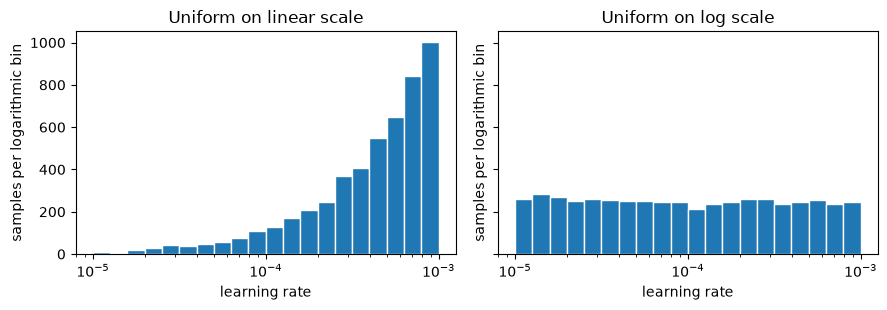

In [10]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(11)
linear = rng.uniform(1e-5, 1e-3, 5_000)
logarithmic = np.exp(rng.uniform(np.log(1e-5), np.log(1e-3), 5_000))
bins = np.logspace(-5, -3, 21)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for axis, values, title in [(axes[0], linear, "Uniform on linear scale"), (axes[1], logarithmic, "Uniform on log scale")]:
    axis.hist(values, bins=bins, edgecolor="white")
    axis.set_xscale("log")
    axis.set(title=title, xlabel="learning rate", ylabel="samples per logarithmic bin")
fig.tight_layout()

### PPO search space in RL Zoo

Zoo's [`sample_ppo_params()`](../../rl_zoo3/hyperparams_opt.py#L108) samples powers of two for rollout and batch sizes, samples `one_minus_gamma` and `one_minus_gae_lambda` logarithmically, samples learning rate and entropy coefficient logarithmically, and treats clipping, epoch count, architecture, and activation as categorical choices. It then converts names such as `one_minus_gamma` into actual PPO arguments.

The course uses this exact checked-out Zoo search space. Open the function and identify which parameters are categorical, integer-valued, linearly sampled, and logarithmically sampled. Notice that Optuna stores the sampled names such as `one_minus_gamma` and `n_steps_pow`; Zoo's [`convert_onpolicy_params()`](../../rl_zoo3/hyperparams_opt.py#L8) converts them into PPO constructor arguments.

In [11]:
# Inspect the exact PPO search-space function used by hp_train.sh.
import inspect
from rl_zoo3.hyperparams_opt import sample_ppo_params

print(inspect.getsource(sample_ppo_params))

def sample_ppo_params(trial: optuna.Trial, n_actions: int, n_envs: int, additional_args: dict) -> dict[str, Any]:
    """
    Sampler for PPO hyperparams.

    :param trial:
    :return:
    """
    # From 2**5=32 to 2**10=1024
    batch_size_pow = trial.suggest_int("batch_size_pow", 2, 10)
    # From 2**5=32 to 2**12=4096
    n_steps_pow = trial.suggest_int("n_steps_pow", 5, 12)
    one_minus_gamma = trial.suggest_float("one_minus_gamma", 0.0001, 0.03, log=True)
    one_minus_gae_lambda = trial.suggest_float("one_minus_gae_lambda", 0.0001, 0.1, log=True)

    learning_rate = trial.suggest_float("learning_rate", 1e-5, 0.002, log=True)
    ent_coef = trial.suggest_float("ent_coef", 0.00000001, 0.1, log=True)
    clip_range = trial.suggest_categorical("clip_range", [0.1, 0.2, 0.3, 0.4])
    n_epochs = trial.suggest_categorical("n_epochs", [1, 5, 10, 20])

    max_grad_norm = trial.suggest_float("max_grad_norm", 0.3, 2)
    net_arch = trial.suggest_categorical("net_arch", ["tiny", "small"

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 5 · The central trade-off: sampler versus pruner

> We want strong hyperparameters while paying for as few complete training runs as possible.

~~~text
Sampler: where should the next trial search?
                         ↓
                  train and evaluate
                         ↓
Pruner: should this running trial receive more budget?
~~~

These are different decisions. A sampler proposes configurations. A pruner uses intermediate results to stop weak configurations before their full budget is spent.

### Samplers

**RandomSampler** draws trials independently. It is simple, easy to parallelize, assumption-light, and a necessary baseline.

**TPE** uses completed observations. Intuitively, it models parameter regions associated with relatively good and less-good outcomes, then proposes values that are more likely under the good model. The first `n_startup_trials` remain random so the model has observations to learn from. See the [Optuna 4.9 TPESampler reference](https://optuna.readthedocs.io/en/v4.9.0/reference/samplers/generated/optuna.samplers.TPESampler.html).

Optuna also supports CMA-ES, Gaussian-process, quasi-Monte Carlo, grid, and other samplers. RL Zoo additionally exposes `auto`, but its code downloads `samplers/auto_sampler` through **OptunaHub**; see the [OptunaHub AutoSampler page](https://hub.optuna.org/samplers/auto_sampler/).

### Pruners

**MedianPruner** compares a trial's intermediate value at an evaluation step with prior trials at the same step. After its startup and warm-up conditions, an underperforming trial can be stopped. Why pay another 500,000 environment transitions when the learning curve is already far behind? See the [MedianPruner reference](https://optuna.readthedocs.io/en/v4.9.0/reference/generated/optuna.pruners.MedianPruner.html).

**SuccessiveHalvingPruner** starts many configurations at a small resource level. At successive rungs, only a better-performing fraction receives more resource. See the [SuccessiveHalvingPruner reference](https://optuna.readthedocs.io/en/v4.9.0/reference/generated/optuna.pruners.SuccessiveHalvingPruner.html).

In Zoo, one Optuna `step` means **one intermediate evaluation**, not one environment transition. [`_create_pruner()`](../../rl_zoo3/exp_manager.py#L791) configures `MedianPruner` with `n_warmup_steps = n_evaluations // 3`; with five evaluations, the first evaluation is warm-up. Zoo names Successive Halving `halving` on the command line. Pruning can save computation, but early RL returns are noisy; aggressive pruning can discard late-learning configurations.

### Median Pruner over the course of a trial

![Median Pruner compares learning curves at intermediate budgets](median_pruner.png)

Each colored line is one trial's performance as its training budget increases. At an evaluation checkpoint, the pruner compares a running trial with the median intermediate performance of earlier trials at the same step. A trial below the reference can be stopped, while stronger trials continue toward the full budget.

The comparison is made checkpoint by checkpoint: a trial is not compared with the final score of already completed trials. Startup trials and warm-up evaluations must first provide a useful reference. Because RL learning curves are noisy and can improve late, the median rule saves computation at the risk of pruning a slow starter.

## 6 · PPO on LunarLander-v3: run and resume a study

The installed stack is Stable-Baselines3 2.9.0 + Gymnasium 1.3.0, so the correct API is `from stable_baselines3 import PPO` and the registered environment is `LunarLander-v3`. The required Box2D dependency is installed in this project environment.

[`hp_train.sh`](scripts/hp_train.sh) collects the important options in one readable command and calls RL Zoo's existing training entry point:

~~~text
CLI configuration
      ↓
train.py → ExperimentManager
      ↓
study.optimize(objective)
      ↓
PPO training + periodic evaluation for each trial
      ↓
SQLite study stores trials and intermediate returns
      ↓
stored trials and best observed parameters
~~~

From the repository root, start the intended 20-trial run:

~~~bash
bash course/lecture_03/scripts/hp_train.sh tpe 20
~~~

The first argument selects `random`, `tpe`, or `auto`; the second selects the number of new trials. `auto` loads the external OptunaHub AutoSampler and may need network access on its first run.

| Setting in `hp_train.sh` | Default | Meaning |
|---|---:|---|
| `N_TRIALS` | 20 | New configurations to test in this invocation |
| `N_JOBS` | 1 | Trials trained concurrently |
| `TIMESTEPS_PER_TRIAL` | 1,000,000 | Maximum PPO training budget per trial |
| `N_EVALUATIONS` | 5 | Intermediate evaluations per trial |
| `EVAL_EPISODES` | 5 | Episodes averaged at each evaluation |
| `N_STARTUP_TRIALS` | 5 | Initial observations before TPE or median pruning adapts |
| `PRUNER` | `median` | Early-stopping rule: `none`, `median`, or `halving` |
| `STUDY_NAME` | `ppo-lunarlander` | Name used to resume the same study |

Zoo calls `optuna.create_study(..., load_if_exists=True)`, so repeating the command with the same study name and database continues the study and adds **20 new trials**. It does not cap the study at 20 total trials. PPO collects complete rollouts, so a trial can slightly exceed the requested number of transitions.

### How many trials run at once? `n_jobs`

`n_jobs` is the maximum number of Optuna trials executed concurrently by one HPO command. It does **not** change PPO's `n_envs`: `n_jobs=2` starts two separate PPO training runs, and each run creates its own vectorized training and evaluation environments. Zoo passes the value directly to [`study.optimize(..., n_jobs=self.n_jobs)`](../../rl_zoo3/exp_manager.py#L961).

~~~text
n_jobs = 1:  trial 0 → trial 1 → trial 2 → ...
n_jobs = 2:  trial 0 ─┐   trial 2 ─┐
             trial 1 ─┘   trial 3 ─┘
~~~

More parallel jobs can reduce wall-clock time, but they do not reduce total computation. They multiply simultaneous CPU, memory, environment, and possibly GPU demand. Too many jobs can therefore make every trial slower or exhaust memory. Parallel trials also finish in a nondeterministic order, so adaptive samplers such as TPE may observe a different history.

**Recommended setting for this exercise:**

- Use `N_JOBS=1` on a normal laptop or when using one GPU. This is the safest and most reproducible starting point.
- Try `N_JOBS=2` only on a machine with enough CPU cores and memory, and check whether trials actually finish faster.
- Do not set `N_JOBS` equal to the total number of CPU cores automatically: every PPO trial already uses 16 LunarLander environments and PyTorch computation.
- The Zoo documentation requires more than one job for its `halving` pruner. Keep the default `median` pruner when running with one job.

Set the value for one command through an environment variable:

~~~bash
N_JOBS=2 bash course/lecture_03/scripts/hp_train.sh tpe 20
~~~

### Intermediate evaluation and pruning

Zoo's [`TrialEvalCallback`](../../rl_zoo3/callbacks.py#L16) subclasses SB3's `EvalCallback`. At each evaluation it:

1. evaluates deterministic policy actions on a separate environment,
2. reports `last_mean_reward` with `trial.report(..., step=evaluation_number)`,
3. asks `trial.should_prune()`, and
4. stops learning and raises `TrialPruned` if requested.

[`ExperimentManager.objective()`](../../rl_zoo3/exp_manager.py#L803) creates training and evaluation environments, attaches this callback, calls `model.learn(...)`, raises `TrialPruned` when requested, and otherwise returns `last_mean_reward`. The current Zoo implementation constructs each trial's PPO model with `seed=None`; the script's `--seed` seeds the sampler, not every PPO trial. This makes the objective noisy and is one reason to validate promising configurations across fresh training seeds.

## 7 · Load and analyze—without training

[`hp_load.sh`](scripts/hp_load.sh) uses Optuna's command-line interface to print the study overview, every trial, and the best completed trial. With no trial number it starts no training:

~~~bash
bash course/lecture_03/scripts/hp_load.sh
~~~

To train a fresh PPO agent with the hyperparameters from trial 7, use:

~~~bash
bash course/lecture_03/scripts/hp_load.sh 7
~~~

The shell script passes `--trial-id 7` to Zoo. [`ExperimentManager.load_trial()`](../../rl_zoo3/exp_manager.py#L384) loads the stored trial parameters and converts Zoo's sampled representation back into PPO arguments. Choose the trial number shown by `Best trial`; do not assume it is always 7. Optuna 4.9 marks its `best-trial` and `trials` CLI commands as experimental, so the shell may also print an `ExperimentalWarning`; this does not invalidate the stored results.

In [17]:
# Run this only after hp_train.sh has created the database.
from optuna.trial import TrialState

database = ROOT / "logs" / "lecture_03" / "hpo" / "ppo_lunarlander.db"
if database.is_file():
    study = optuna.load_study(study_name="ppo-lunarlander", storage=f"sqlite:///{database.resolve()}")
    states = {state.name: len(study.get_trials(states=(state,))) for state in TrialState}
    complete_trials = study.get_trials(states=(TrialState.COMPLETE,))
    print("trial states:", states)
    display(study.trials_dataframe().head(20))
    if complete_trials:
        print("best trial:", study.best_trial.number)
        print("best value:", study.best_value)
        print("best parameters:", study.best_params)
    else:
        print("No trial has completed yet.")
else:
    print("No course study yet. Run hp_train.sh first.")

trial states: {'RUNNING': 0, 'COMPLETE': 18, 'PRUNED': 2, 'FAIL': 0, 'WAITING': 0}


,number,value,datetime_start,datetime_complete,duration,params_activation_fn,params_batch_size_pow,params_clip_range,params_ent_coef,params_learning_rate,params_max_grad_norm,params_n_epochs,params_n_steps_pow,params_net_arch,params_one_minus_gae_lambda,params_one_minus_gamma,user_attrs_batch_size,user_attrs_gamma,user_attrs_n_steps,state
0,0,105.946887,2026-09-21 10:05:32.405689,2026-09-21 11:18:41.044089,0 days 01:13:08.638400,tanh,2,0.1,2.324115e-06,0.000017,1.704198,10,8,small,0.015868,0.000401,4,0.999599,256,PRUNED
1,1,-193.014250,2026-09-21 10:05:32.407355,2026-09-21 10:37:02.670924,0 days 00:31:30.263569,relu,5,0.4,5.416312e-07,0.000012,1.067407,10,10,tiny,0.000752,0.021009,32,0.978991,1024,COMPLETE
2,2,-213.188460,2026-09-21 10:05:32.415780,2026-09-21 10:30:51.988969,0 days 00:25:19.573189,relu,6,0.2,2.984997e-04,0.000014,0.424004,10,11,medium,0.004738,0.002741,64,0.997259,2048,COMPLETE
3,3,-5120.054697,2026-09-21 10:05:32.420404,2026-09-21 10:15:36.537941,0 days 00:10:04.117537,relu,4,0.4,1.256334e-06,0.000014,1.620052,1,5,medium,0.000346,0.005440,16,0.994560,32,COMPLETE
4,4,-2337.713250,2026-09-21 10:15:36.546234,2026-09-21 10:18:30.202780,0 days 00:02:53.656546,relu,7,0.1,1.876091e-08,0.000026,1.787966,1,8,medium,0.046323,0.002152,128,0.997848,256,COMPLETE
5,5,-21.967110,2026-09-21 10:18:30.211035,2026-09-21 10:20:27.885342,0 days 00:01:57.674307,tanh,9,0.3,5.869101e-03,0.001414,0.902956,1,10,tiny,0.014643,0.002675,512,0.997325,1024,COMPLETE
6,6,289.998840,2026-09-21 10:20:27.895503,2026-09-21 10:28:26.639971,0 days 00:07:58.744468,relu,8,0.4,2.452518e-04,0.001549,1.753297,10,8,medium,0.051240,0.000386,256,0.999614,256,COMPLETE
7,7,-371.508652,2026-09-21 10:28:26.647100,2026-09-21 10:35:18.602069,0 days 00:06:51.954969,relu,7,0.4,1.988189e-04,0.000036,1.746629,5,9,small,0.000274,0.003162,128,0.996838,512,COMPLETE
8,8,-41.271817,2026-09-21 10:30:51.996297,2026-09-21 10:33:30.805570,0 days 00:02:38.809273,relu,8,0.4,1.233675e-05,0.000904,1.830149,1,10,medium,0.000836,0.000391,256,0.999609,1024,COMPLETE
9,9,275.142282,2026-09-21 10:33:30.811726,2026-09-21 10:42:18.932153,0 days 00:08:48.120427,relu,8,0.4,3.007003e-02,0.000140,1.702135,10,9,medium,0.011533,0.000222,256,0.999778,512,COMPLETE


best trial: 6
best value: 289.9988404
best parameters: {'batch_size_pow': 8, 'n_steps_pow': 8, 'one_minus_gamma': 0.00038601134847897356, 'one_minus_gae_lambda': 0.05124012395761566, 'learning_rate': 0.0015487066292875222, 'ent_coef': 0.00024525182607346423, 'clip_range': 0.4, 'n_epochs': 10, 'max_grad_norm': 1.7532974783950148, 'net_arch': 'medium', 'activation_fn': 'relu'}


### Which plots answer which question?

| Plot | Question it answers | Caveat |
|---|---|---|
| Optimization history | Did the best observed result improve as trials accumulated? | Does not prove generalization |
| Parameter importance | Which dimensions matter for reaching the better half of observed scores? | PED-ANOVA is unstable with few completed/diverse trials |
| Slice plot | How does score vary with each parameter? | Associations include interactions and noise |
| Parallel coordinates | Which combinations occur in strong trials? | Becomes cluttered with many parameters/trials |

The following notebook cell creates all four because each answers a different question. It explicitly uses [PED-ANOVA](https://optuna.readthedocs.io/en/v4.9.0/reference/generated/optuna.importance.PedAnovaImportanceEvaluator.html) with `target_quantile=0.5`. PED-ANOVA is marked experimental in Optuna 4.9 and recommends at least five trials in the selected top group, so importance conclusions should wait for roughly ten or more complete trials here. See Optuna's [visualization tutorial](https://optuna.readthedocs.io/en/v4.9.0/tutorial/10_key_features/005_visualization.html).

In [18]:
# Interactive notebook visualizations after a study exists.
if database.is_file():
    from optuna.importance import PedAnovaImportanceEvaluator
    from optuna.visualization import (
        plot_optimization_history,
        plot_parallel_coordinate,
        plot_param_importances,
        plot_slice,
    )

    plot_optimization_history(study).show()
    plot_slice(study).show()
    plot_parallel_coordinate(study).show()
    if len(study.get_trials(states=(TrialState.COMPLETE,))) >= 10:
        evaluator = PedAnovaImportanceEvaluator(target_quantile=0.5)
        plot_param_importances(study, evaluator=evaluator).show()
    else:
        print("Parameter importance needs about ten complete trials for this setting.")

/var/folders/x2/5xjcy7yn54q23v2y61hks79r0000gn/T/ipykernel_1314/2029972089.py:15: ExperimentalWarning: PedAnovaImportanceEvaluator is experimental (supported from v3.6.0). The interface can change in the future.
  evaluator = PedAnovaImportanceEvaluator(target_quantile=0.5)


## 8 · What persistence means

A relational Optuna study stores trial parameters, objective values, states, intermediate values, timestamps/durations, and study/trial attributes. The SQLite database allows later processes to resume or analyze the same named study. See Optuna's [Study API](https://optuna.readthedocs.io/en/v4.9.0/reference/generated/optuna.study.Study.html).

It does **not** automatically store PPO network weights, checkpoints, TensorBoard logs, or videos. `study.best_params` returns the best observed **sampled configuration**, not a trained agent. In Zoo, that dictionary may contain encoded keys such as `one_minus_gamma` or `n_steps_pow`; [`load_trial()`](../../rl_zoo3/exp_manager.py#L384) applies the algorithm-specific converter before PPO is constructed.

~~~bash
# Replace 7 with the best trial number printed by hp_load.sh.
bash course/lecture_03/scripts/hp_load.sh 7
~~~

This starts a **new training run** with the selected hyperparameters. Loading already-trained weights would instead require a saved `.zip` model, but the Optuna study itself does not contain one.

## 9 · Reproducibility and RL-specific pitfalls

- Training and evaluation are stochastic; a return is an estimate, not a property measured without error.
- More evaluation episodes reduce evaluation noise but consume more simulator time.
- A fixed evaluation seed improves comparability but can encourage overfitting to a narrow set of trajectories.
- Selecting the best among many noisy trials creates a winner's-curse effect: the maximum is partly luck.
- Do not treat the best single trial as objectively best. Re-train promising configurations across several fresh seeds.
- Keep a final evaluation set of seeds/budget separate from the hyperparameter search, and report the distribution or mean with uncertainty.

A practical workflow is **search cheaply → shortlist → re-train across seeds → final evaluation**. Hyperparameter search chooses candidates; it does not replace experimental validation.

## 10 · End-to-end map

~~~text
lecture_03.ipynb
    ↓ explains concepts and source locations
scripts/hp_train.sh
    ↓ configures RL Zoo and starts PPO trials
logs/lecture_03/hpo/ppo_lunarlander.db
    ↓ persists the named Optuna study
scripts/hp_load.sh
    ↓ prints trials and can retrain a selected trial
notebook analysis cells
    ↓ DataFrame and interactive Optuna plots
~~~

The shell scripts expose the experiment settings; RL Zoo owns study creation, trial execution, PPO training, evaluation, pruning, storage, and parameter conversion.

## 11 · Homework (for next week): your PPO hyperparameter study

Each student runs one hyperparameter optimization for **PPO on new supply chain environment**.

1. Choose one Optuna sampler supported by the course script: `random`, `tpe`, or `auto`,... Read its Optuna/OptunaHub documentation until you can explain how it proposes the next configuration.
2. Start 50 new trials, for example:

   ~~~bash
   bash course/lecture_03/scripts/hp_train.sh tpe 50
   ~~~

   Replace `tpe` with your chosen sampler. Keep the default PPO environment, search space, trial budget, and median pruner so the class results remain comparable.
3. Inspect the study with `bash course/lecture_03/scripts/hp_load.sh` and execute the notebook analysis cells. Record the best completed trial number, its evaluation reward, and its sampled parameters.
4. Prepare a brief presentation for the next session—about one minute—with exactly these points:

   - Which sampler did you choose?
   - How does it select the next trial?
   - How many trials completed and how many were pruned?
   - What was your best observed evaluation reward?
   - Which hyperparameters produced it?

The best observed trial is a noisy screening result, not proof that this configuration is universally best. Do not start the optional million-step retraining unless requested separately.

## Sources used where they matter

- [Bergstra & Bengio (2012), JMLR](https://jmlr.org/papers/v13/bergstra12a.html) — random versus grid search.
- [Optuna 4.9 documentation](https://optuna.readthedocs.io/en/v4.9.0/) — study/trial APIs, samplers, pruners, persistence, and visualization.
- [Stable-Baselines3 2.9.0 PPO documentation](https://stable-baselines3.readthedocs.io/en/v2.9.0/modules/ppo.html) — exact PPO constructor/API.
- [RL Baselines3 Zoo tuning documentation](https://rl-baselines3-zoo.readthedocs.io/en/master/guide/tuning.html) and the checked-out [`exp_manager.py`](../../rl_zoo3/exp_manager.py), [`hyperparams_opt.py`](../../rl_zoo3/hyperparams_opt.py), and [`callbacks.py`](../../rl_zoo3/callbacks.py) — exact integration used in this repository.